# Rock-Paper-Scissors Image Classification with CNNs

This notebook explores convolutional neural networks for image classification. It starts with CNN parameter and memory calculations, visualizes how hand-crafted convolution filters respond to an image, then trains and evaluates two rock-paper-scissors classifiers: a custom CNN trained from scratch and a MobileNetV2 transfer-learning model.

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

## CNN Parameter Counts and Memory Requirements

This section estimates the number of trainable parameters and the minimum memory needed for a forward pass through a three-layer convolutional network.

For a convolutional layer with kernel size $F \times F$, input channels $D_{in}$, and $K$ output feature maps:

$\text{weights} = F \times F \times D_{in} \times K$

$\text{biases} = K$

$\text{trainable parameters} = \text{weights} + \text{biases}$

Given three convolutional layers with $3 \times 3$ kernels:

Layer 1: RGB input with 3 channels and 64 output feature maps

$3 \times 3 \times 3 \times 64 = 1,728$ weights

$64$ biases

Layer 2: 64 input channels and 128 output feature maps

$3 \times 3 \times 64 \times 128 = 73,728$ weights

$128$ biases

Layer 3: 128 input channels and 256 output feature maps

$3 \times 3 \times 128 \times 256 = 294,912$ weights

$256$ biases

Totals:

$\text{weights} = 1,728 + 73,728 + 294,912 = 370,368$

$\text{biases} = 64 + 128 + 256 = 448$

$\text{trainable parameters} = 370,368 + 448 = 370,816$

### Forward-Pass Memory Estimate

For 32-bit floating point values, each stored value requires 4 bytes. During training, activation maps from each layer must be stored so gradients can be computed during backpropagation.

The input image has shape $256 \times 512 \times 3$.

With valid padding, a $3 \times 3$ kernel, and stride 2, the output size for each spatial dimension is:

$\left\lfloor \frac{n - 3}{2} \right\rfloor + 1$

Layer output shapes:

- Layer 1: $127 \times 255 \times 64$
- Layer 2: $63 \times 127 \times 128$
- Layer 3: $31 \times 63 \times 256$

Activation memory:

- Input: $256 \times 512 \times 3 \times 4 = 1,572,864$ bytes
- Layer 1: $127 \times 255 \times 64 \times 4 = 8,290,560$ bytes
- Layer 2: $63 \times 127 \times 128 \times 4 = 4,096,512$ bytes
- Layer 3: $31 \times 63 \times 256 \times 4 = 1,999,872$ bytes

Parameter memory:

$370,816 \times 4 = 1,483,264$ bytes

Approximate minimum memory for one forward pass during training:

$1,572,864 + 8,290,560 + 4,096,512 + 1,999,872 + 1,483,264 = 17,443,072$ bytes

$17,443,072 / 1,048,576 \approx 16.64$ MiB

This is a lower-bound estimate because training frameworks also use memory for gradients, optimizer state, temporary tensors, and framework overhead.

## Visualizing Hand-Crafted Convolution Filters

The next section applies several hand-crafted convolution filters to a grayscale image of Nelson Mandela. This illustrates how different kernels emphasize edges, texture, and local contrast.

Each row below shows the grayscale image, the filter kernel, and the resulting feature map for one convolution filter.

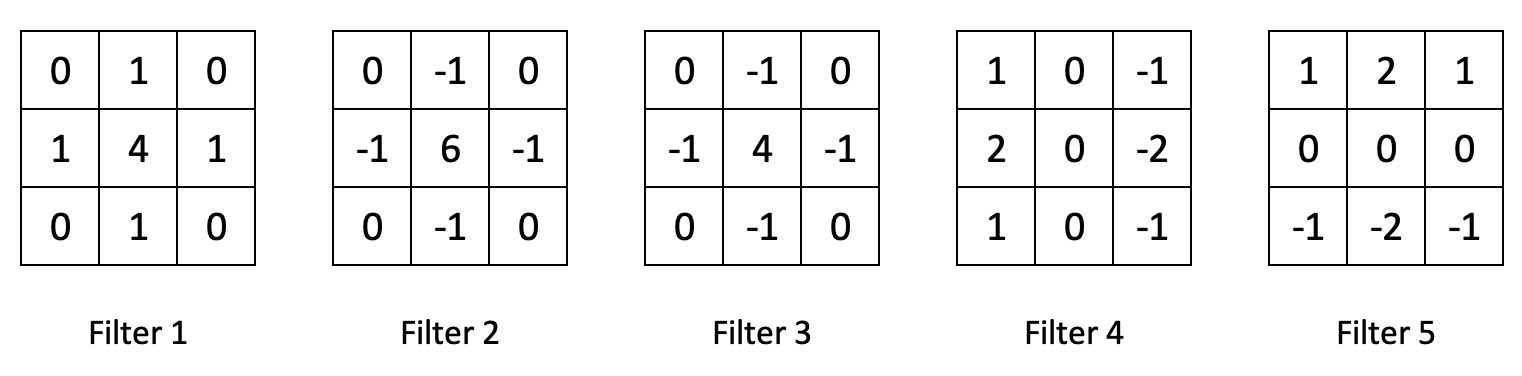

(-0.5, 439.5, 568.5, -0.5)

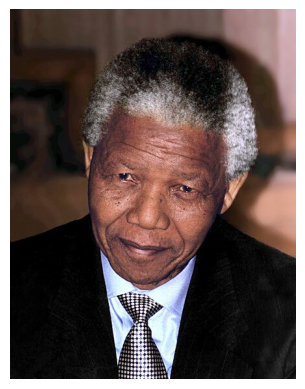

In [8]:
from urllib.request import Request, urlopen
from PIL import Image
from io import BytesIO

url = "https://upload.wikimedia.org/wikipedia/commons/thumb/0/02/Nelson_Mandela_1994.jpg/440px-Nelson_Mandela_1994.jpg"

req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urlopen(req) as r:
    img = Image.open(BytesIO(r.read())).convert("RGB")


plt.imshow(img)
plt.axis("off")





(-0.5, 439.5, 568.5, -0.5)

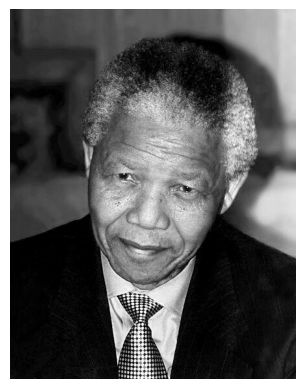

In [ ]:
#Gray scale
gray = np.array(img)[:, :, 0]
plt.imshow(gray, cmap="gray")
plt.axis("off")

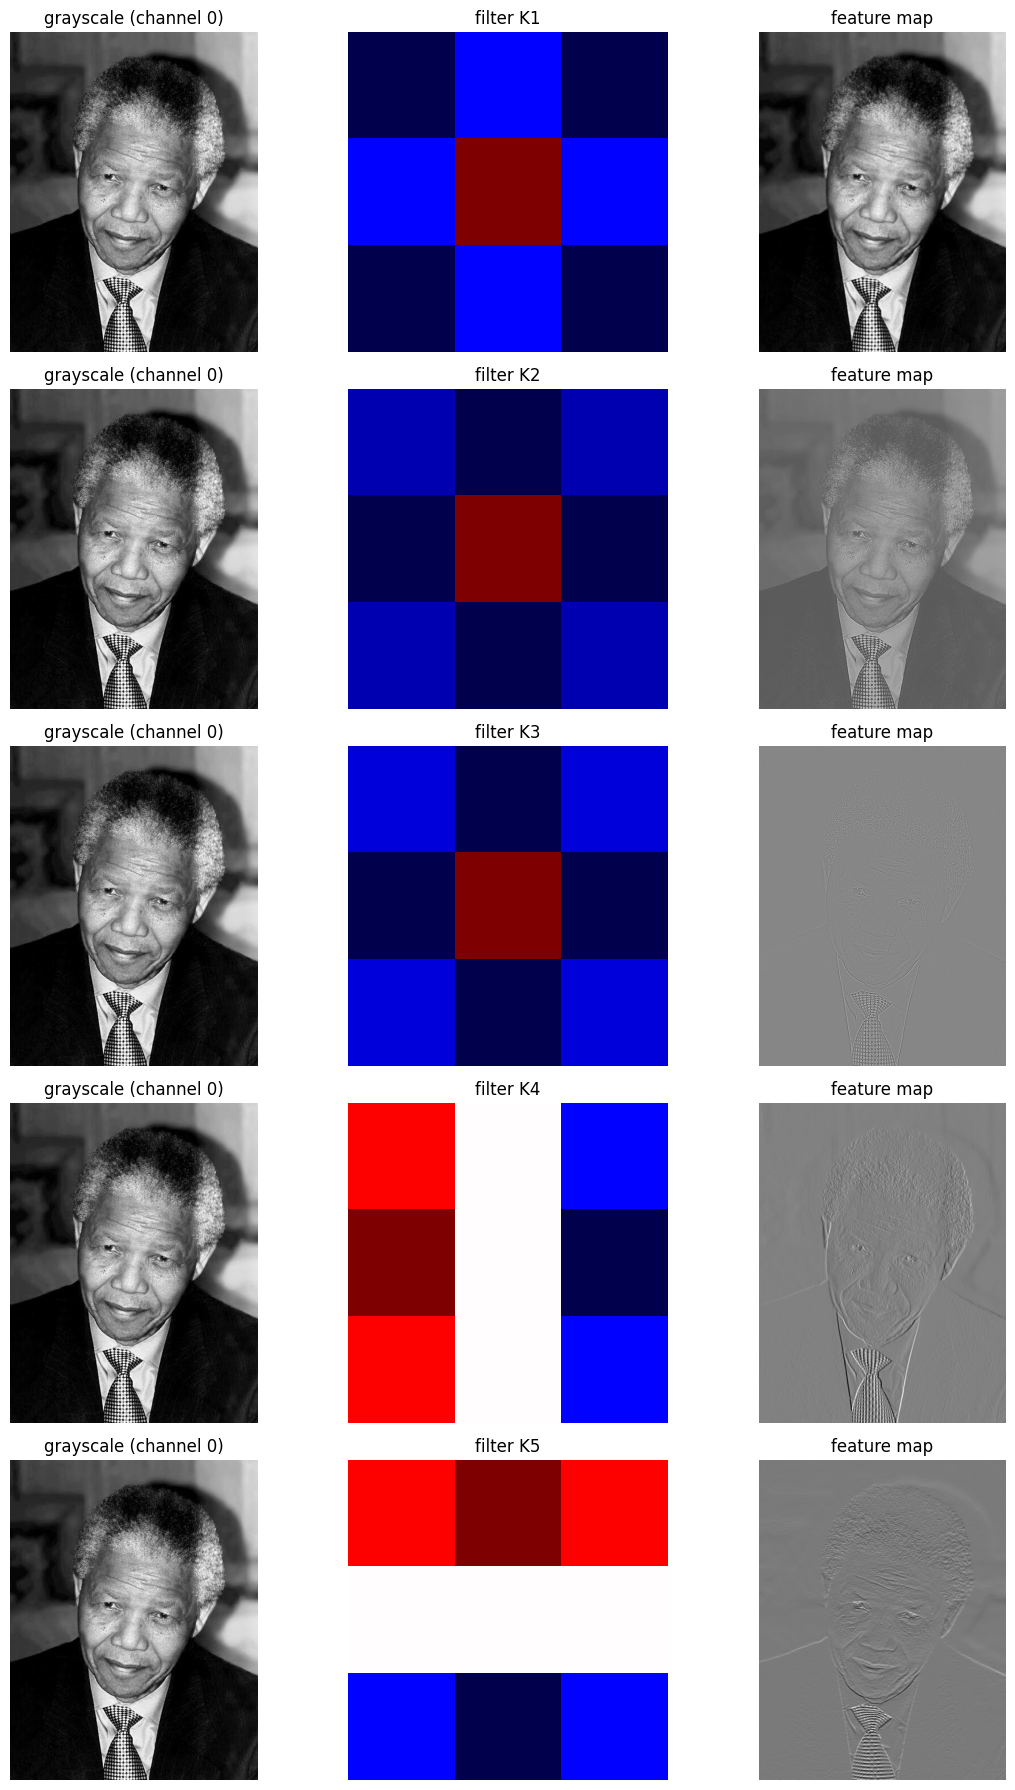

In [ ]:
#convert to 4D and normalize by dividing by 255. 
# #Converts NumPy into PyTorch tensor
# adds a new dimension
# permutes to have the order (N, C, H, W) bc PyTorch nn.Conv2d expects inputs in NCHW order.

gray_3d = gray[:, :, None]  # (H, W, 1)
new_img = torch.unsqueeze(torch.tensor(gray_3d), dim=0).permute(0, 3, 1, 2) / 255 #(1,1,H,W)


# given filters
K1 = torch.tensor([[0, 1, 0],
                   [1, 4, 1],
                   [0, 1, 0]], dtype=torch.float32)

K2 = torch.tensor([[0, -1, 0],
                   [-1, 6, -1],
                   [0, -1, 0]], dtype=torch.float32)

K3 = torch.tensor([[0, -1, 0],
                   [-1, 4, -1],
                   [0, -1, 0]], dtype=torch.float32)

K4 = torch.tensor([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]], dtype=torch.float32)

K5 = torch.tensor([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]], dtype=torch.float32)

kernels = [K1, K2, K3, K4, K5]

#filters tensor: (num_filters, kh, kw, channels)
filters = torch.zeros([5, 3, 3, 1])
for i, K in enumerate(kernels):
    filters[i, :, :, 0] = K

#conv layer + copy weights 
conv_layer = nn.Conv2d(1, 5, kernel_size=3, padding=0, stride=1, bias=False)
conv_layer.weight.data.copy_(filters.permute(0, 3, 1, 2))

#feature maps
fmaps = conv_layer(new_img).detach()  # (1, 5, H_out, W_out)

#plot 5x3
fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for i in range(5):
    axes[i, 0].imshow(gray, cmap="gray")
    axes[i, 0].set_title("grayscale (channel 0)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(kernels[i], cmap="seismic")
    axes[i, 1].set_title(f"filter K{i+1}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(fmaps[0, i], cmap="gray")
    axes[i, 2].set_title("feature map")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


## Dataset: Rock-Paper-Scissors

This project uses the [Rock-Paper-Scissors dataset from Kaggle](https://www.kaggle.com/datasets/sanikamal/rock-paper-scissors-dataset). The dataset contains image folders for three classes: `paper`, `rock`, and `scissors`.

To run the notebook locally, download and unzip the dataset, then place it in this relative structure:

```text
data/Rock-Paper-Scissors/train/
data/Rock-Paper-Scissors/test/
```

The notebook uses the training folder for model training and validation, with 320 images reserved for validation. The test folder is used only for final evaluation.

In [ ]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.random.manual_seed(17)  # notebook-style reproducibility

train_dir = "data/Rock-Paper-Scissors/train"
test_dir  = "data/Rock-Paper-Scissors/test"

# Basic transforms
basic_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])

# Full training dataset
ds_train_full = datasets.ImageFolder(train_dir, transform=basic_transforms)

#Split: exactly 320 
val_size = 320
train_size = len(ds_train_full) - val_size
ds_train, ds_val = random_split(
    ds_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(17)
)

# Test dataset
ds_test = datasets.ImageFolder(test_dir, transform=basic_transforms)

print("Classes:", ds_train_full.classes)
print("Class to idx:", ds_train_full.class_to_idx)
print("Sizes:", len(ds_train), len(ds_val), len(ds_test))

# DataLoaders (batch size 32)
# If you see hanging issues on Mac, set num_workers=0.
dl_train = DataLoader(ds_train, batch_size=32, shuffle=True,  num_workers=0)
dl_val   = DataLoader(ds_val,   batch_size=32, shuffle=False, num_workers=0)
dl_test  = DataLoader(ds_test,  batch_size=32, shuffle=False, num_workers=0)

#QC
X, y = next(iter(dl_train))
print("Batch X:", X.shape, "Batch y:", y.shape)


Classes: ['paper', 'rock', 'scissors']
Class to idx: {'paper': 0, 'rock': 1, 'scissors': 2}
Sizes: 2200 320 372
Batch X: torch.Size([32, 3, 96, 96]) Batch y: torch.Size([32])


## Model 1: CNN Trained from Scratch

The first model is a custom convolutional neural network trained with PyTorch Lightning. Training uses image augmentation to improve generalization, including resizing, random horizontal flipping, random rotation, and color jitter.

In [50]:
# Data augmentation: color jitter adds color variation beyond geometric transforms.

from torchvision import transforms

torch.random.manual_seed(17)


train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),   
    transforms.RandomRotation(10),            
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
])


In [52]:
from torch.utils.data import DataLoader, Subset, random_split
import lightning as L
from torchvision import datasets, transforms


#Lightning Data Module (same idea as DogsVsCatsDataModule)
class RPSDataModule(L.LightningDataModule):
    def __init__(self, train_dir, test_dir, transform=transform, train_transform=None, batch_size=32, val_size=320):
        super().__init__()
        self.train_dir = train_dir
        self.test_dir = test_dir
        self.transform = transform
        self.train_transform = transform if train_transform is None else train_transform
        self.batch_size = batch_size
        self.val_size = val_size

    def setup(self, stage=None):
        # two "views" of the SAME train folder: augmented for train, non-aug for val
        ds_full_aug  = datasets.ImageFolder(self.train_dir, transform=self.train_transform)
        ds_full_eval = datasets.ImageFolder(self.train_dir, transform=self.transform)

        train_size = len(ds_full_aug) - self.val_size

        idx_train, idx_val = random_split(
            range(len(ds_full_aug)),
            [train_size, self.val_size],
            generator=torch.Generator().manual_seed(17)
        )

        self.ds_train = Subset(ds_full_aug,  idx_train.indices)
        self.ds_val   = Subset(ds_full_eval, idx_val.indices)
        self.ds_test  = datasets.ImageFolder(self.test_dir, transform=self.transform)

        self.class_names = ds_full_aug.classes
        self.num_classes = len(self.class_names)

    def train_dataloader(self):
        return DataLoader(self.ds_train, batch_size=self.batch_size, shuffle=True, num_workers=0)

    def val_dataloader(self):
        return DataLoader(self.ds_val, batch_size=self.batch_size, shuffle=False, num_workers=0)

    def test_dataloader(self):
        return DataLoader(self.ds_test, batch_size=self.batch_size, shuffle=False, num_workers=0)


train_dir = "data/Rock-Paper-Scissors/train"
test_dir  = "data/Rock-Paper-Scissors/test"

rps_dm = RPSDataModule(train_dir, test_dir, train_transform=train_transform, batch_size=32, val_size=320)
rps_dm.setup()

print("Classes:", rps_dm.class_names)
print("Sizes:", len(rps_dm.ds_train), len(rps_dm.ds_val), len(rps_dm.ds_test))




Classes: ['paper', 'rock', 'scissors']
Sizes: 2200 320 372


In [53]:
# Base module
class BaseModule(L.LightningModule):
    def __init__(self, lr=0.001, num_classes=3):
        super().__init__()
        self.lr = lr

        self.train_accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy   = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy  = Accuracy(task="multiclass", num_classes=num_classes)

    def _common_step(self, batch, batch_idx, accuracy, loss_lbl, accuracy_lbl):
        X, y = batch
        logits = self(X)
        loss = nn.functional.cross_entropy(logits, y)
        y_hat = torch.argmax(logits, dim=1)
        self.log(loss_lbl, loss, prog_bar=True)
        self.log(accuracy_lbl, accuracy(y_hat, y), prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._common_step(batch, batch_idx, self.train_accuracy, "loss", "accuracy")

    def on_training_epoch_end(self):
        self.log("accuracy", self.train_accuracy.compute())
        self.train_accuracy.reset()

    def validation_step(self, batch, batch_idx):
        return self._common_step(batch, batch_idx, self.val_accuracy, "val_loss", "val_accuracy")

    def on_validation_epoch_end(self):
        self.log("val_accuracy", self.val_accuracy.compute())
        self.val_accuracy.reset()

    def test_step(self, batch, batch_idx):
        return self._common_step(batch, batch_idx, self.test_accuracy, "test_loss", "test_accuracy")

    def on_test_epoch_end(self):
        self.log("test_accuracy", self.test_accuracy.compute())
        self.test_accuracy.reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [54]:
# Model with nn.Sequential
from torchmetrics import Accuracy

class RPSModelV01(BaseModule):
    def __init__(self, num_classes=3, lr=0.001):
        super().__init__(lr=lr, num_classes=num_classes)

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Dropout1d(p=.3),
            nn.Linear(64 * 12 * 12, 128),  # because 96 -> 48 -> 24 -> 12 after 3 pools
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = RPSModelV01(num_classes=rps_dm.num_classes, lr=1e-3)


In [55]:
# Summary (notebook style)
from torchinfo import summary


summary(model, input_size=(32, 3, 96, 96))

Layer (type:depth-idx)                   Output Shape              Param #
RPSModelV01                              [32, 3]                   --
├─Sequential: 1-1                        [32, 3]                   --
│    └─Conv2d: 2-1                       [32, 16, 96, 96]          448
│    └─BatchNorm2d: 2-2                  [32, 16, 96, 96]          32
│    └─ReLU: 2-3                         [32, 16, 96, 96]          --
│    └─MaxPool2d: 2-4                    [32, 16, 48, 48]          --
│    └─Conv2d: 2-5                       [32, 32, 48, 48]          4,640
│    └─BatchNorm2d: 2-6                  [32, 32, 48, 48]          64
│    └─ReLU: 2-7                         [32, 32, 48, 48]          --
│    └─MaxPool2d: 2-8                    [32, 32, 24, 24]          --
│    └─Conv2d: 2-9                       [32, 64, 24, 24]          18,496
│    └─BatchNorm2d: 2-10                 [32, 64, 24, 24]          128
│    └─ReLU: 2-11                        [32, 64, 24, 24]          --
│    └

In [56]:
#Train + save best + test best
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

logger = CSVLogger("logs", name="rps_scratch_v1_0")

callbacks = [
    ModelCheckpoint(
        dirpath="checkpoints",
        filename="rps-scratch-{epoch:02d}-{val_accuracy:.4f}",
        monitor="val_accuracy",
        mode="max",
        save_top_k=1,
    ),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=5),
]

trainer = L.Trainer(
    max_epochs=20,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=logger,
    callbacks=callbacks,
)

trainer.fit(model, datamodule=rps_dm)

print("Best checkpoint:", trainer.checkpoint_callback.best_model_path)

trainer.test(datamodule=rps_dm, ckpt_path="best")


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 1 │ val_accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ test_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ model          │ Sequential         │  1.2 M │ train │     0 │
└───┴────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Restoring states from the checkpoint path at checkpoints/rps-scratch-epoch=02-val_accuracy=1.0000-v1.ckpt
Loaded model weights from the checkpoint at checkpoints/rps-scratch-epoch=02-val_accuracy=1.0000-v1.ckpt


Output()

Best checkpoint: checkpoints/rps-scratch-epoch=02-val_accuracy=1.0000-v1.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8897849321365356     │
│         test_loss         │    0.39716729521751404    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.39716729521751404, 'test_accuracy': 0.8897849321365356}]

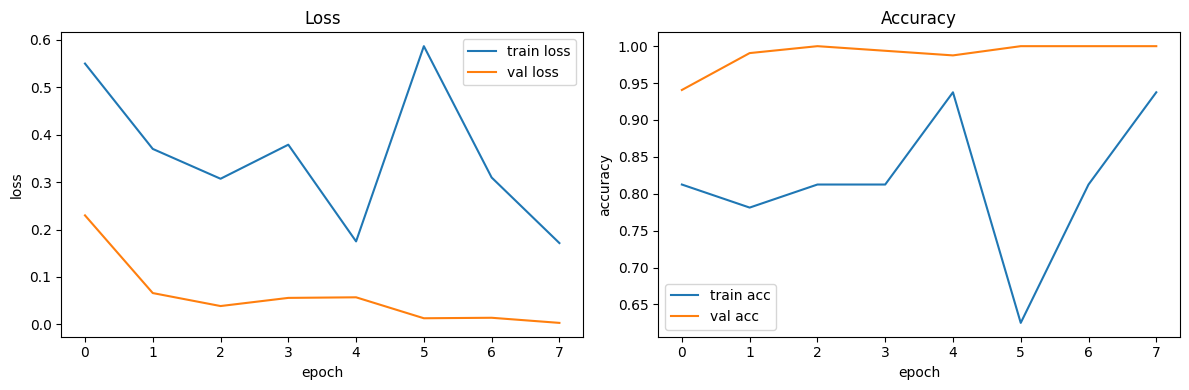

In [57]:
# Learning curves from CSVLogger 
import os

metrics_path = os.path.join(logger.log_dir, "metrics.csv")
df = pd.read_csv(metrics_path)

train_loss = df.dropna(subset=["loss"]).groupby("epoch")["loss"].last()
val_loss   = df.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].last()
train_acc  = df.dropna(subset=["accuracy"]).groupby("epoch")["accuracy"].last()
val_acc    = df.dropna(subset=["val_accuracy"]).groupby("epoch")["val_accuracy"].last()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss.index, train_loss.values, label="train loss")
plt.plot(val_loss.index, val_loss.values, label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_acc.index, train_acc.values, label="train acc")
plt.plot(val_acc.index, val_acc.values, label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Accuracy")

plt.tight_layout()
plt.show()

## Model 2: MobileNetV2 Transfer Learning

The second model uses a pretrained MobileNetV2 backbone with a new classification head for the three rock-paper-scissors classes. This provides a comparison between a custom CNN trained from scratch and a pretrained computer vision model adapted to the task.

In [60]:
from torchvision import models
class MobileNetV2ModelV01(BaseModule):
    def __init__(self, num_classes=3, lr=1e-4):
        super().__init__(lr=lr, num_classes=num_classes)

        self.model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.model.eval()

        # freeze feature extractor (base)
        for p in self.model.features.parameters():
            p.requires_grad = False

        # replace top for 3 classes
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

mobilenet_model = MobileNetV2ModelV01(num_classes=rps_dm.num_classes, lr=1e-4)

# Summarize
summary(mobilenet_model, input_size=(32, 3, 96, 96))

logger_tl = CSVLogger("logs", name="rps_mobilenetv2_v1_0")

callbacks_tl = [
    ModelCheckpoint(
        dirpath="checkpoints",
        filename="rps-mobilenetv2-{epoch:02d}-{val_accuracy:.4f}",
        monitor="val_accuracy",
        mode="max",
        save_top_k=1,
    ),
    EarlyStopping(monitor="val_accuracy", mode="max", patience=5),
]

trainer_tl = L.Trainer(
    max_epochs=10,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    logger=logger_tl,
    callbacks=callbacks_tl,
)

trainer_tl.fit(mobilenet_model, datamodule=rps_dm)

print("Best checkpoint:", trainer_tl.checkpoint_callback.best_model_path)

trainer_tl.test(datamodule=rps_dm, ckpt_path="best")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to ~/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 35.2MB/s]
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/anaconda3/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 1 │ val_accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ test_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ model          │ MobileNetV2        │  2.2 M │ train │     0 │
└───┴────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 3.8 K                                                                                            
Non-trainable params: 2.2 M                                                                                        
Total params: 2.2 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 216                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

/opt/anaconda3/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Best checkpoint: checkpoints/rps-mobilenetv2-epoch=08-val_accuracy=0.9438.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8198924660682678     │
│         test_loss         │    0.5814558267593384     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.5814558267593384, 'test_accuracy': 0.8198924660682678}]

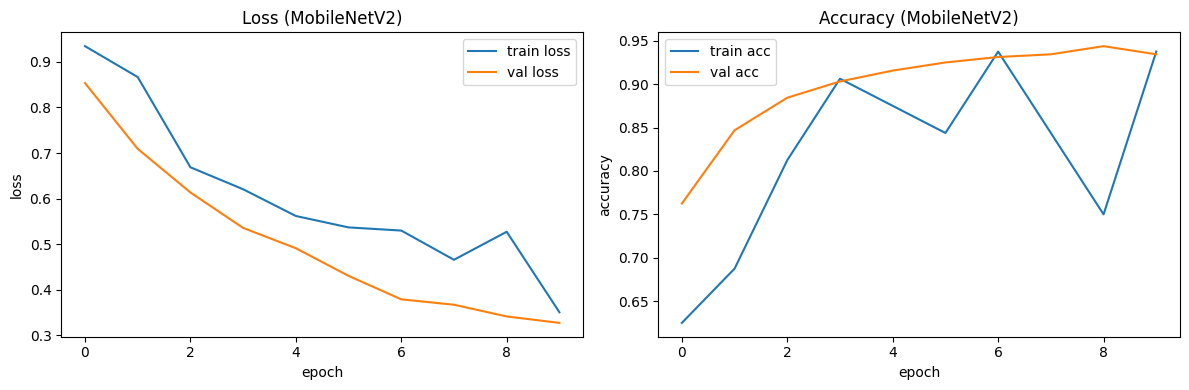

In [61]:
metrics_path = os.path.join(logger_tl.log_dir, "metrics.csv")
df = pd.read_csv(metrics_path)

train_loss = df.dropna(subset=["loss"]).groupby("epoch")["loss"].last()
val_loss   = df.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].last()
train_acc  = df.dropna(subset=["accuracy"]).groupby("epoch")["accuracy"].last()
val_acc    = df.dropna(subset=["val_accuracy"]).groupby("epoch")["val_accuracy"].last()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss.index, train_loss.values, label="train loss")
plt.plot(val_loss.index, val_loss.values, label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss (MobileNetV2)")

plt.subplot(1, 2, 2)
plt.plot(train_acc.index, train_acc.values, label="train acc")
plt.plot(val_acc.index, val_acc.values, label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("Accuracy (MobileNetV2)")

plt.tight_layout()
plt.show()

## Conclusion

The custom CNN trained from scratch achieved the stronger final test result in this run, with approximately **88.98% test accuracy** and **0.397 test loss**. The MobileNetV2 transfer-learning model reached approximately **81.99% test accuracy** and **0.581 test loss**.

Although pretrained models often perform well with limited data, the simpler CNN was better matched to this small three-class image task. This comparison shows why model selection should be driven by validation and test performance rather than assuming a larger pretrained architecture will always be superior.

Key takeaways:

- Convolution filters can be interpreted visually by examining their feature maps.
- Data augmentation helps expose the model to realistic image variation.
- A compact CNN can perform strongly on a focused classification problem.
- Transfer learning is useful, but it still requires careful tuning and evaluation.